# Import Prerequisites

In [57]:
import numpy as np
import pandas as pd
from glob import glob
from datetime import date, timedelta
import datetime
import math
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 15, 9

# Dataset Processing

In [58]:
case_time = pd.read_csv('../districts.csv', parse_dates = True)
case_time

,Date,State,District,Confirmed,Recovered,Deceased,Other,Tested
0,2020-04-26,Andaman and Nicobar Islands,Unknown,33,11,0,0,2679.0
1,2020-04-26,Andhra Pradesh,Anantapur,53,14,4,0,NaN
2,2020-04-26,Andhra Pradesh,Chittoor,73,13,0,0,NaN
3,2020-04-26,Andhra Pradesh,East Godavari,39,12,0,0,NaN
4,2020-04-26,Andhra Pradesh,Guntur,214,29,8,0,NaN
...,...,...,...,...,...,...,...,...
258555,2021-06-02,West Bengal,Purba Bardhaman,36025,33876,129,0,NaN
258556,2021-06-02,West Bengal,Purba Medinipur,49755,45957,326,0,NaN
258557,2021-06-02,West Bengal,Purulia,18613,17974,107,0,NaN
258558,2021-06-02,West Bengal,South 24 Parganas,87233,79996,1111,0,NaN


In [59]:
case_time = case_time[["Date","State","District","Confirmed","Recovered","Deceased"]]
case_time

,Date,State,District,Confirmed,Recovered,Deceased
0,2020-04-26,Andaman and Nicobar Islands,Unknown,33,11,0
1,2020-04-26,Andhra Pradesh,Anantapur,53,14,4
2,2020-04-26,Andhra Pradesh,Chittoor,73,13,0
3,2020-04-26,Andhra Pradesh,East Godavari,39,12,0
4,2020-04-26,Andhra Pradesh,Guntur,214,29,8
...,...,...,...,...,...,...
258555,2021-06-02,West Bengal,Purba Bardhaman,36025,33876,129
258556,2021-06-02,West Bengal,Purba Medinipur,49755,45957,326
258557,2021-06-02,West Bengal,Purulia,18613,17974,107
258558,2021-06-02,West Bengal,South 24 Parganas,87233,79996,1111


In [105]:
state = "Gujarat"
state_data = case_time[case_time['State'] == state]
state_data

,Date,State,District,Confirmed,Recovered,Deceased
45,2020-04-26,Gujarat,Ahmedabad,2181,140,104
46,2020-04-26,Gujarat,Anand,49,14,3
47,2020-04-26,Gujarat,Aravalli,18,0,1
48,2020-04-26,Gujarat,Banaskantha,28,1,0
49,2020-04-26,Gujarat,Bharuch,29,14,2
...,...,...,...,...,...,...
258050,2021-06-02,Gujarat,Surat,141146,135928,1914
258051,2021-06-02,Gujarat,Surendranagar,8080,7836,136
258052,2021-06-02,Gujarat,Tapi,4390,4161,19
258053,2021-06-02,Gujarat,Vadodara,75410,69410,771


In [106]:
district_list = state_data['District'].unique()

district_data = dict()
district_data_21 = dict()
for districts in district_list:
    district_data.update({districts:0})
for districts in district_list:
    district_data_21.update({districts:0})

In [107]:
#calander like dataframe

sdate = date(2020, 1, 1)
edate = date(2020, 12, 31)

delta = edate - sdate
dates = []

for i in range(delta.days + 1):
    day = sdate + timedelta(days=i)
    dates.append(day)

In [108]:
print("Preparing chronological district data for year 2020")
print("|| ",end="")
for district in district_data:
    active = []
    cal_dat = pd.DataFrame(columns=['Date','State','District','Confirmed','Recovered','Deceased'])
    cal_dat['Date'] = dates
    cal_dat.set_index('Date',inplace=True)
    
    buff_data = state_data[state_data['District'] == district]
    for i in buff_data.index:
        x = (buff_data.loc[i])
        for dt in cal_dat.index:
            if x[0] == str(dt):
                cal_dat.loc[dt] = x  

            
    for i in cal_dat.index:
        if not math.isnan(cal_dat.loc[i,['Confirmed']]):
            a = int(cal_dat.loc[i,['Confirmed']]) - int(cal_dat.loc[i,['Recovered']]) - int(cal_dat.loc[i,['Deceased']])
            active.append(a)
        else:
            active.append('DNA')
        
    cal_dat['State'] = cal_dat['State'].replace(np.nan, x[1])
    cal_dat['District'] = cal_dat['District'].replace(np.nan, district)
    cal_dat['Recovered'] = cal_dat['Recovered'].replace(np.nan, 'DNA')
    cal_dat['Deceased'] = cal_dat['Deceased'].replace(np.nan, 'DNA')
    cal_dat['Confirmed'] = cal_dat['Confirmed'].replace(np.nan, 'DNA')
    cal_dat['Active'] = active
    district_data[district] = cal_dat
    print("=",end="")
print(" ||")

Preparing chronological district data for year 2020
|| ================================== ||


In [109]:
#calander like dataframe

sdate = date(2021, 1, 1)
edate = date(2021, 5, 30)

delta = edate - sdate
dates_21 = []

for i in range(delta.days + 1):
    day = sdate + timedelta(days=i)
    dates_21.append(day)

In [110]:
print("Preparing chronological district data for year 2021")
print("|| ",end="")
for district in district_data:
    active = []
    cal_dat = pd.DataFrame(columns=['Date','State','District','Confirmed','Recovered','Deceased'])
    cal_dat['Date'] = dates_21
    cal_dat.set_index('Date',inplace=True)
    
    buff_data = state_data[state_data['District'] == district]
    for i in buff_data.index:
        x = (buff_data.loc[i])
        for dt in cal_dat.index:
            if x[0] == str(dt):
                cal_dat.loc[dt] = x 
            
    for i in cal_dat.index:
        if not math.isnan(cal_dat.loc[i,['Confirmed']]):
            a = int(cal_dat.loc[i,['Confirmed']]) - int(cal_dat.loc[i,['Recovered']]) - int(cal_dat.loc[i,['Deceased']])
            active.append(a)
        else:
            active.append('DNA')
        
    cal_dat['State'] = cal_dat['State'].replace(np.nan, x[1])
    cal_dat['District'] = cal_dat['District'].replace(np.nan, district)
    cal_dat['Recovered'] = cal_dat['Recovered'].replace(np.nan, 'DNA')
    cal_dat['Deceased'] = cal_dat['Deceased'].replace(np.nan, 'DNA')
    cal_dat['Confirmed'] = cal_dat['Confirmed'].replace(np.nan, 'DNA')
    cal_dat['Active'] = active
    district_data_21[district] = cal_dat
    print("=",end="")
print(" ||")

Preparing chronological district data for year 2021
|| ================================== ||


Trend of Active cases in Ahmedabad for the year 2020


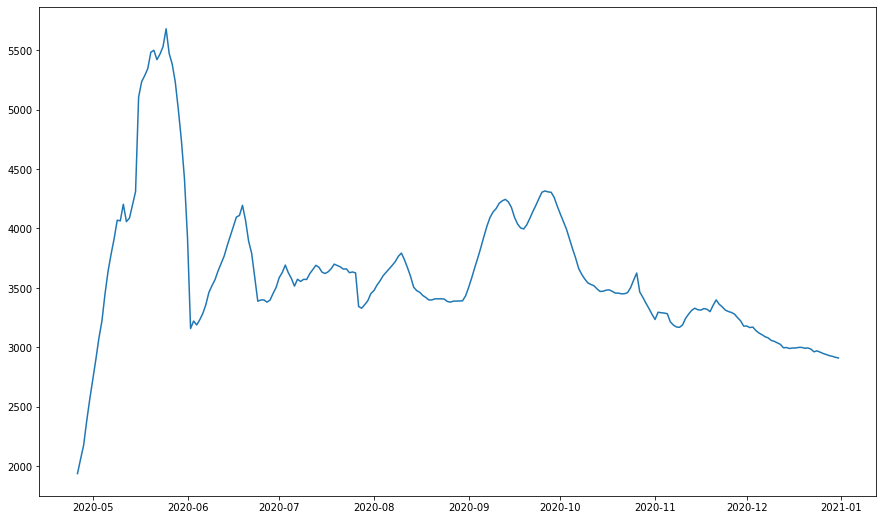

In [111]:
district = 'Ahmedabad'
bang_data = district_data[district][district_data[district]['Active'] != 'DNA']
bang_data = bang_data[["Active"]]
bang_data = bang_data.astype(int)
print("Trend of Active cases in",district,"for the year 2020")
plt.plot(bang_data)

Trend of Active cases in Ahmedabad for the year 2021


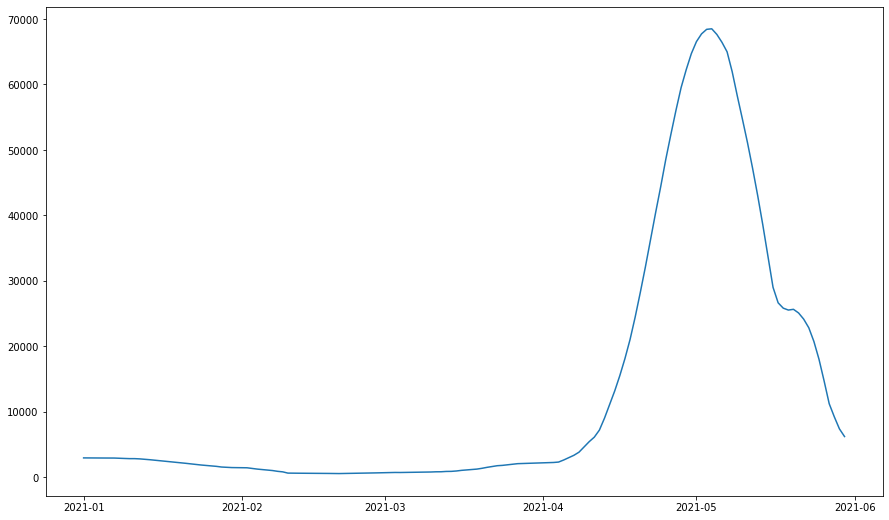

In [112]:
bang_data_21 = district_data_21[district][district_data_21[district]['Active'] != 'DNA']
bang_data_21 = bang_data_21[["Active"]]
bang_data_21 = bang_data_21.astype(int)
print("Trend of Active cases in",district,"for the year 2021")
plt.plot(bang_data_21)

In [113]:
#Quarter-wise div

quart_data = bang_data[bang_data.index >= datetime.date(2020, 1, 1)]
quart1_data = bang_data[quart_data.index < datetime.date(2020, 4, 1)]

quart_data = bang_data[bang_data.index >= datetime.date(2020, 4, 1)]
quart2_data = bang_data[quart_data.index < datetime.date(2020, 7, 1)]

quart_data = bang_data[bang_data.index >= datetime.date(2020, 7, 1)]
quart3_data = quart_data[quart_data.index < datetime.date(2020, 10, 1)]

quart4_data = bang_data[bang_data.index >= datetime.date(2020, 10, 1)]

COVID-19 cases in Ahmedabad
            Active
Date              
2020-04-26    1937
2020-04-27    2058
2020-04-28    2174
2020-04-29    2377
2020-04-30    2561
...            ...
2020-12-27    2939
2020-12-28    2930
2020-12-29    2924
2020-12-30    2916
2020-12-31    2910

[250 rows x 1 columns]
            Active
Date              
2021-01-01    2909
2021-01-02    2902
2021-01-03    2900
2021-01-04    2894
2021-01-05    2891
...            ...
2021-05-26   14679
2021-05-27   11190
2021-05-28    9188
2021-05-29    7349
2021-05-30    6175

[150 rows x 1 columns]


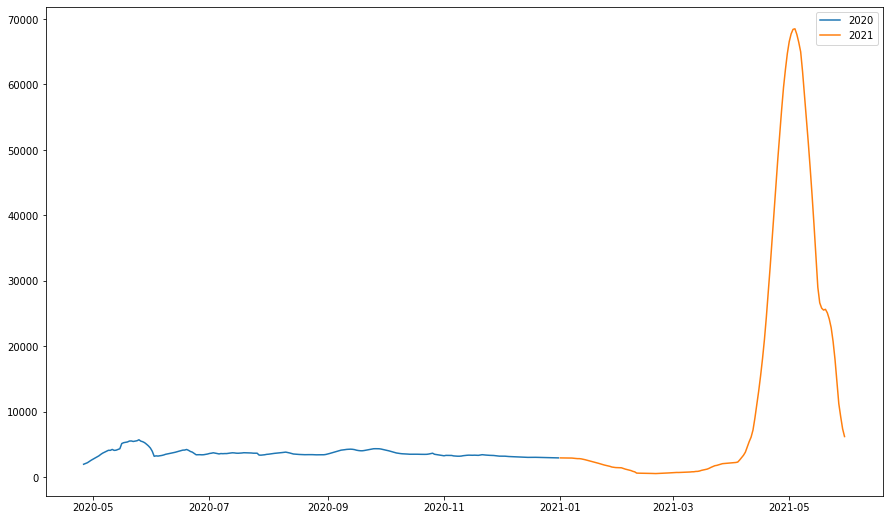

In [114]:
print("COVID-19 cases in",district)
print(bang_data)
print(bang_data_21)
plt.plot(bang_data)
plt.plot(bang_data_21)
plt.legend(['2020','2021'])

# Stationarity check and Transformations

In [115]:
from statsmodels.tsa.stattools import adfuller

(-2.6197008756136606, 0.08899347261674456, 12, 237, {'1%': -3.4582467982399105, '5%': -2.8738137461081323, '10%': -2.5733111490323846}, 2746.220239654457)
Non stationary


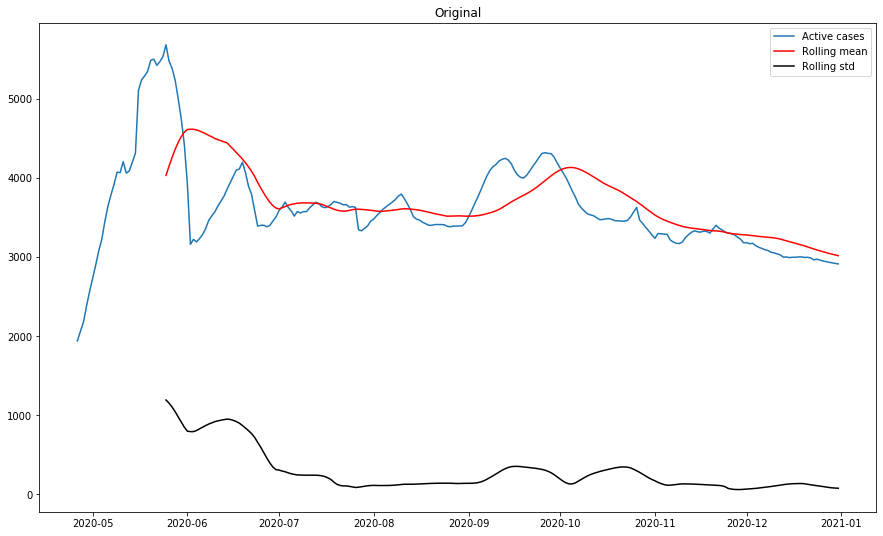

In [116]:
rolmean = bang_data.rolling(window=30).mean()
rolstd = bang_data.rolling(window=30).std()
org = plt.plot(bang_data, label = 'Active cases')
mean = plt.plot(rolmean.dropna(), color = 'Red', label = 'Rolling mean')
std = plt.plot(rolstd.dropna(), color = 'Black', label = 'Rolling std')
plt.legend()
plt.title('Original')

adftst = adfuller(bang_data['Active'], autolag = 'AIC')
print(adftst)

if(adftst[1] < 0.05):
    print('Stationary')
else:
    print('Non stationary')

In [117]:
# Sqrt to fix non-stationarity
bang_data_sqrt = np.sqrt(bang_data)

# Differencing method
bang_data_second = bang_data_sqrt.diff(1)
bang_data_second = bang_data_second.dropna()

(-6.121149361604966, 8.849111548160667e-08, 1, 247, {'1%': -3.457105309726321, '5%': -2.873313676101283, '10%': -2.5730443824681606}, 493.69597248468625)
Stationary


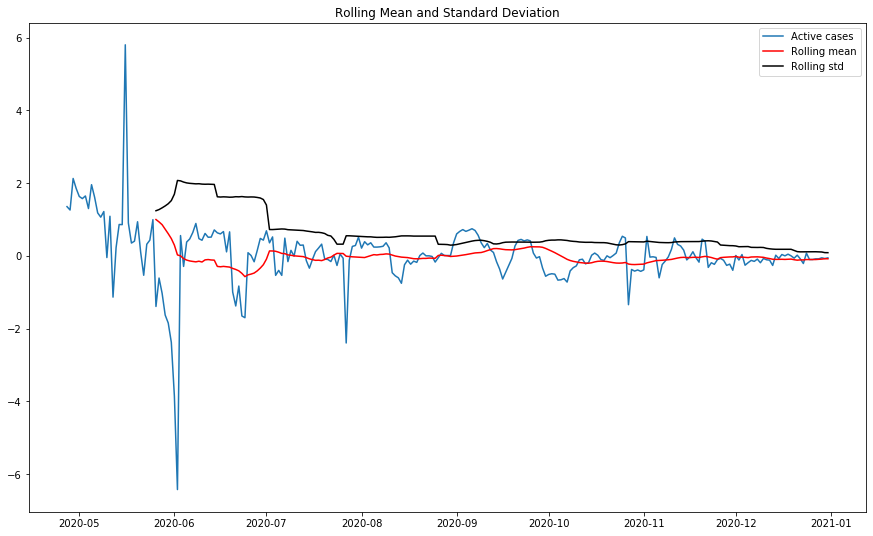

In [118]:
rolmean = bang_data_second.rolling(window=30).mean()
rolstd = bang_data_second.rolling(window=30).std()
org = plt.plot(bang_data_second, label = 'Active cases')
mean = plt.plot(rolmean.dropna(), color = 'Red', label = 'Rolling mean')
std = plt.plot(rolstd.dropna(), color = 'Black', label = 'Rolling std')
plt.legend()
plt.title('Rolling Mean and Standard Deviation')


adftst = adfuller(bang_data_second['Active'].dropna(), autolag = 'AIC')
print(adftst)

if(adftst[1] < 0.05):
    print('Stationary')
else:
    print('Non stationary')

# Parameters for ARIMA

In [119]:
from pmdarima import auto_arima
step_fit = auto_arima(bang_data_second['Active'].dropna(), trace = True)
step_fit.summary()

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=540.892, Time=0.35 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=637.051, Time=0.02 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=545.954, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=579.647, Time=0.03 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=635.583, Time=0.01 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=539.208, Time=0.07 sec
 ARIMA(0,0,2)(0,0,0)[0] intercept   : AIC=558.341, Time=0.05 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=537.764, Time=0.07 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=539.326, Time=0.10 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=537.764, Time=0.05 sec
 ARIMA(3,0,0)(0,0,0)[0] intercept   : AIC=539.165, Time=0.17 sec
 ARIMA(3,0,1)(0,0,0)[0] intercept   : AIC=537.370, Time=0.18 sec
 ARIMA(4,0,1)(0,0,0)[0] intercept   : AIC=539.128, Time=0.23 sec
 ARIMA(3,0,2)(0,0,0)[0] intercept   : AIC=535.994, Time=0.27 sec
 ARIMA(4,0,2)(0,0,0)[0] intercept   : AIC=540.5

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  249
Model:               SARIMAX(3, 0, 3)   Log Likelihood                -258.257
Date:                Fri, 04 Jun 2021   AIC                            530.515
Time:                        10:09:49   BIC                            555.137
Sample:                             0   HQIC                           540.425
                                - 249                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.0920      0.066    -16.472      0.000      -1.222      -0.962
ar.L2          0.4923      0.110      4.462      0.000       0.276       0.709
ar.L3          0.7491      0.050     14.950      0.000       0.651       0.847
ma.L1          1.5951      0.099     16.180      0.000       1.402       1.788
ma.L2          0.3936      0.185      2.124      0.034       0.030       0.757
ma.L3         -0.2907      0.101     -2.884      0.004      -0.488      -0.093
sigma2         0.4581      0.022     21.015      0.000       0.415       0.501
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):              3390.52
Prob(Q):                              0.90   Prob(JB):                         0.00
Heteroskedasticity (H):               0.06   Skew:                             0.94
Prob(H) (two-sided):                  0.00   Kurtosis:                        20.98
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

ACF and PACF plots


Text(0.5, 1.0, 'Partial Autocorrelation function')

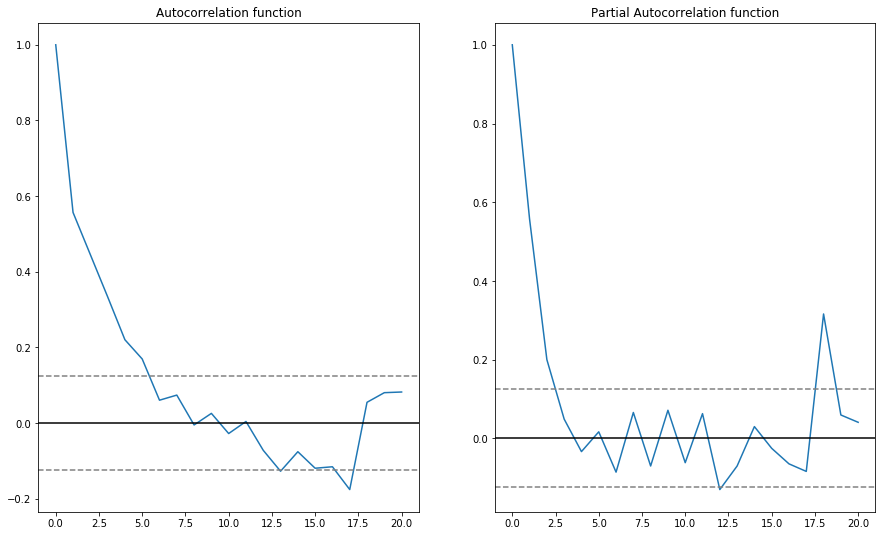

In [120]:
#ACF and PACF
from statsmodels.tsa.stattools import acf,pacf

lag_acf = acf(bang_data_second['Active'].dropna(), nlags = 20)
lag_pacf = pacf(bang_data_second['Active'].dropna(), nlags = 20, method = 'ols')
print("ACF and PACF plots")

# ACF
plt.subplot(121)
plt.plot(lag_acf)
plt.axhline(y = 0, linestyle = '-', color = 'black')
plt.axhline(y=-1.96/np.sqrt(len(bang_data_second)),linestyle='--',color = 'gray')
plt.axhline(y=1.96/np.sqrt(len(bang_data_second)),linestyle='--',color = 'gray')
plt.title('Autocorrelation function')

# ACF
plt.subplot(122)
plt.plot(lag_pacf)
plt.axhline(y = 0, linestyle = '-', color = 'black')
plt.axhline(y=-1.96/np.sqrt(len(bang_data_second)),linestyle='--',color = 'gray')
plt.axhline(y=1.96/np.sqrt(len(bang_data_second)),linestyle='--',color = 'gray')
plt.title('Partial Autocorrelation function')

ACF and PACF corellograms


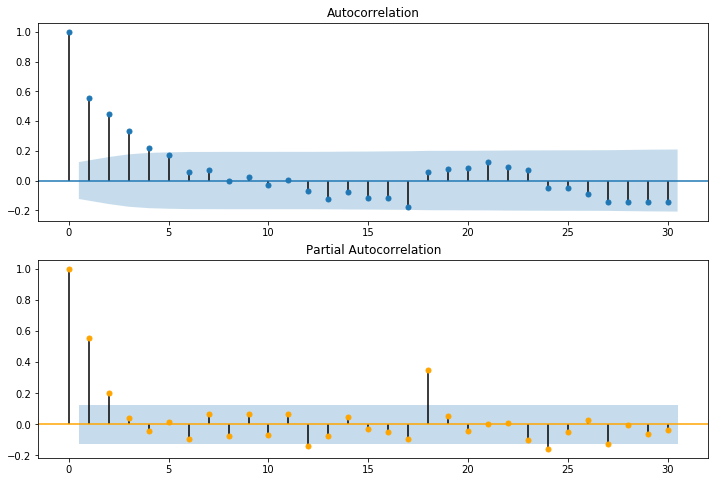

In [121]:
import statsmodels.api as sm

print("ACF and PACF corellograms")
fig = plt.figure(figsize=(12,8))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(bang_data_second['Active'].dropna(),lags = 30, ax = ax1)

ax2 = fig.add_subplot(212)
fig = sm.graphics.tsa.plot_pacf(bang_data_second['Active'].dropna(),lags = 30, color='orange', ax = ax2)

# ARIMA model forecasts 

AR model
MSE :  0.4898156929968237


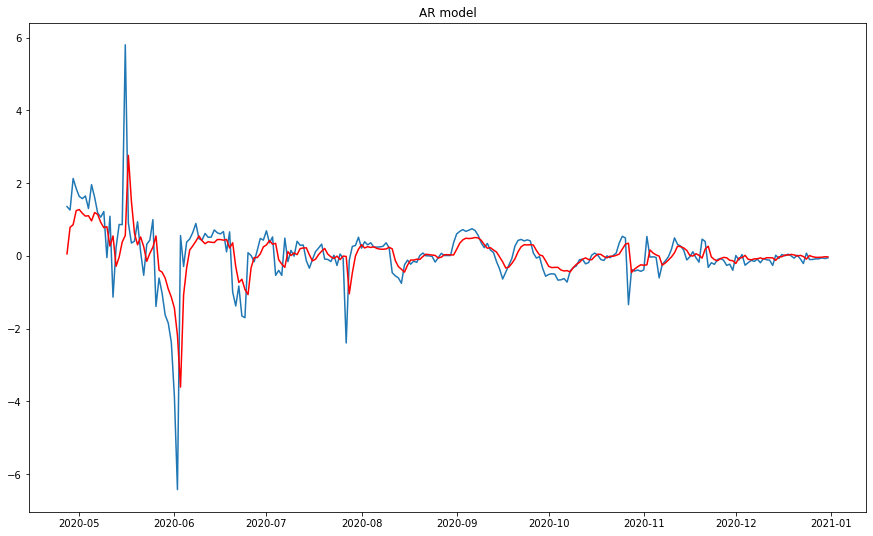

In [127]:
from statsmodels.tsa.arima_model import ARIMA

print("AR model")
model = ARIMA(bang_data_sqrt,order = (3,1,0))
res_AR = model.fit(disp=-1)
plt.plot(bang_data_second)
plt.plot(res_AR.fittedvalues, color = 'red')
plt.title('AR model')
mse = 1/len(bang_data_sqrt)*sum((res_AR.fittedvalues-bang_data_second['Active'].dropna())**2)
print('MSE : ',mse)

MA model
0.5061984419218408


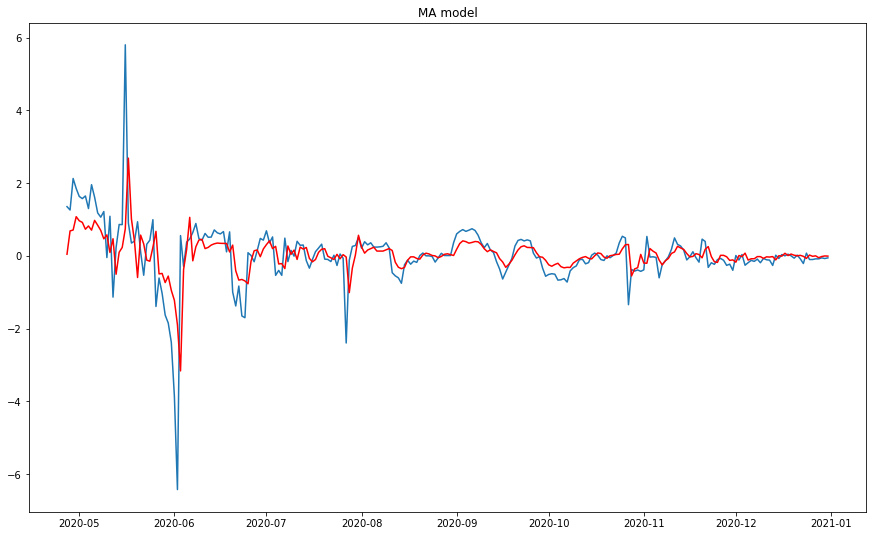

In [128]:
print("MA model")
model = ARIMA(bang_data_sqrt,order = (0,1,3))
res_MA = model.fit(disp=-1)
plt.plot(bang_data_second)
plt.plot(res_MA.fittedvalues, color = 'red')
plt.title('MA model')
mse = 1/len(bang_data_sqrt)*sum((res_MA.fittedvalues-bang_data_second['Active'].dropna())**2)
print(mse)

ARIMA model
0.48482331541949525


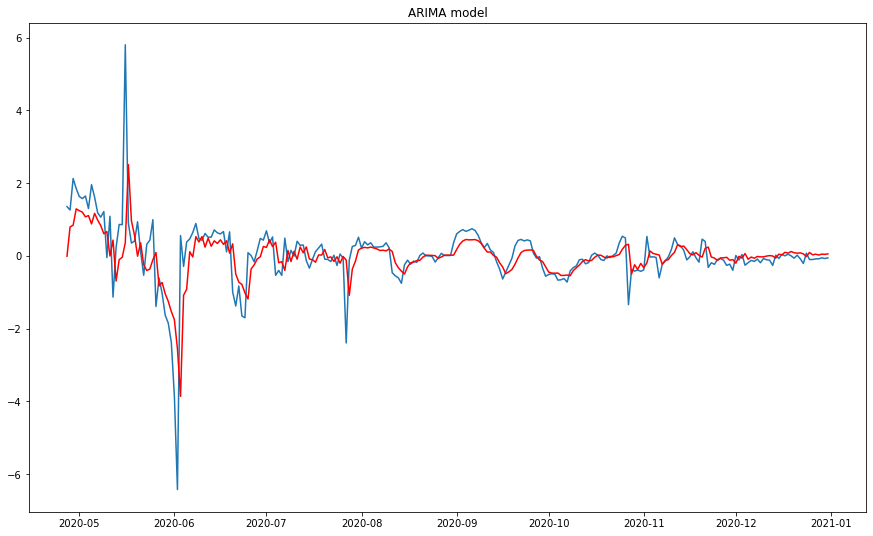

In [129]:
print("ARIMA model")
model = ARIMA(bang_data_sqrt,order = (3,1,3))
res_ARIMA = model.fit(disp=-1)
plt.plot(bang_data_second)
plt.plot(res_ARIMA.fittedvalues, color = 'red')
plt.title('ARIMA model')
mse = 1/len(bang_data_sqrt)*sum((res_ARIMA.fittedvalues-bang_data_second['Active'].dropna())**2)
print(mse)

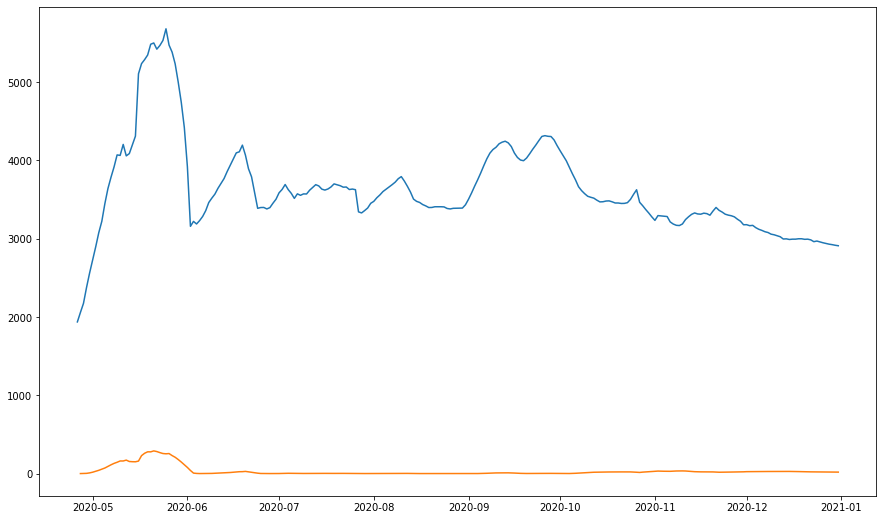

In [130]:
pred_arima = pd.Series(res_ARIMA.fittedvalues, copy=True)
pred_arima = pred_arima.cumsum()
pred_fin = (pred_arima**2)
plt.plot(bang_data)
plt.plot(pred_fin)

In [131]:
def get_err(ress):
    lst = bang_data_21.values
    sm = 0
    l = min(len(bang_data_21),len(ress))
    for i in range(l):
        x = ((lst[i]-ress[i])/lst[i])**2
        sm = sm + x
    rmse = 100 - (math.sqrt(sm/l))*100
    return rmse

In [132]:
rmse_for_tab = []
for i in range(1,15):
    period = int(i)
    r = res_ARIMA.forecast(steps=period)
    ress = r[0]**2
    rmse = get_err(ress)
    rmse_for_tab.append(rmse)

In [133]:
eval_matrix = pd.DataFrame(columns=['Time frame','Date','All data'])

In [134]:
tim = []

print("Confidence Interval of forecast over 1st test interval")
for i in range(len(rmse_for_tab)):
    tim.append((i+1))
eval_matrix['Time frame'] = tim
eval_matrix['Date'] = bang_data_21.index[:14]
eval_matrix['All data'] = rmse_for_tab
eval_matrix.set_index('Time frame',inplace=True)
eval_matrix

Confidence Interval of forecast over 1st test interval


,Date,All data
Time frame,,
1,2021-01-01,99.779480
2,2021-01-02,99.479595
3,2021-01-03,98.922304
4,2021-01-04,98.536159
5,2021-01-05,98.056166
6,2021-01-06,97.586447
7,2021-01-07,97.053625
8,2021-01-08,96.202238
9,2021-01-09,95.283251


Forecast of trend of growth of COVID-19 for the 1st test interval
               Forecast  Daily forecast  Confidence interval  Actual  Daily
Date                                                                       
2021-01-01  2915.414926               5            99.779480    2909     -1
2021-01-02  2927.445847              12            99.479595    2902     -7
2021-01-03  2942.745358              15            98.922304    2900     -2
2021-01-04  2962.369737              20            98.536159    2894     -6
2021-01-05  2983.877778              21            98.056166    2891     -3
2021-01-06  3007.892920              24            97.586447    2892      1
2021-01-07  3032.637378              25            97.053625    2886     -6
2021-01-08  3058.474948              26            96.202238    2848    -38
2021-01-09  3084.123183              26            95.283251    2824    -24
2021-01-10  3109.800954              25            94.296502    2797    -27
2021-01-11  3134.60110

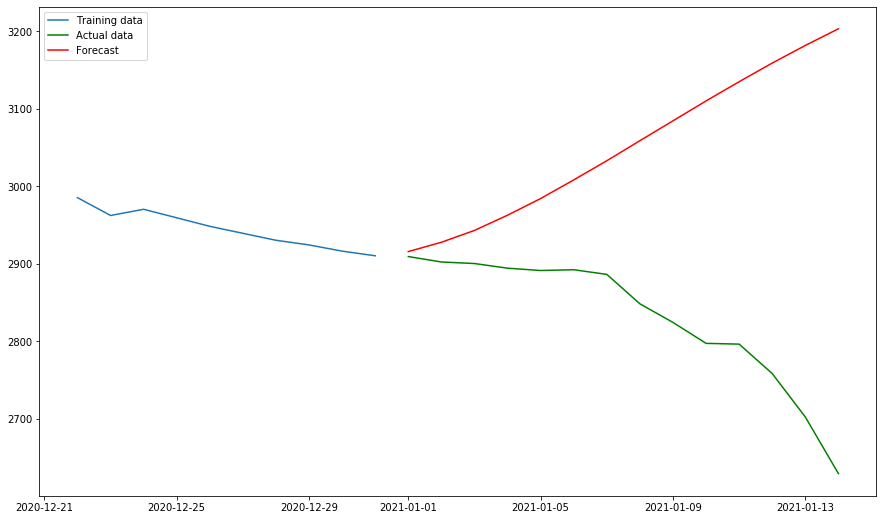

In [135]:
dt = bang_data.index[-1]
end = dt + datetime.timedelta(days=len(ress)+1)
step = datetime.timedelta(days=1)
dtframe = []
while dt < end:
    dte = (dt.strftime('%Y-%m-%d'))
    dtframe.append((datetime.datetime.strptime(dte, '%Y-%m-%d')).date())
    dt += step
    
print("Forecast of trend of growth of COVID-19 for the 1st test interval")
daily = []
tst = pd.DataFrame()
tst['Date'] = dtframe[1:]
tst['Forecast'] = ress
daily.append(int(ress[0])-int(bang_data[-1:].values))
for i in range(1,len(ress)):
    daily.append(int(ress[i])-int(ress[i-1]))
tst['Daily forecast'] = daily
tst['Confidence interval'] = rmse_for_tab
tst['Actual'] = bang_data_21.values[:len(ress)]
cum = bang_data_21.values
daily = []
daily.append(int(cum[0])-int(bang_data[-1:].values))
for i in range(1,len(ress)):
    daily.append(int(cum[i])-int(cum[i-1]))
tst['Daily'] = daily
tst.set_index('Date',inplace=True)

print(tst)
plt.plot(bang_data[-10:])
plt.plot(bang_data_21[:len(ress)],color='green')
plt.plot(tst['Forecast'],color='red')
plt.legend(['Training data','Actual data','Forecast'])

# Forecasts over 2nd test interval

(-2.7623035521213435, 0.06386345148055783, 13, 386, {'1%': -3.447405233596701, '5%': -2.8690569369014605, '10%': -2.5707743450830893}, 5161.82735823728)
Non stationary


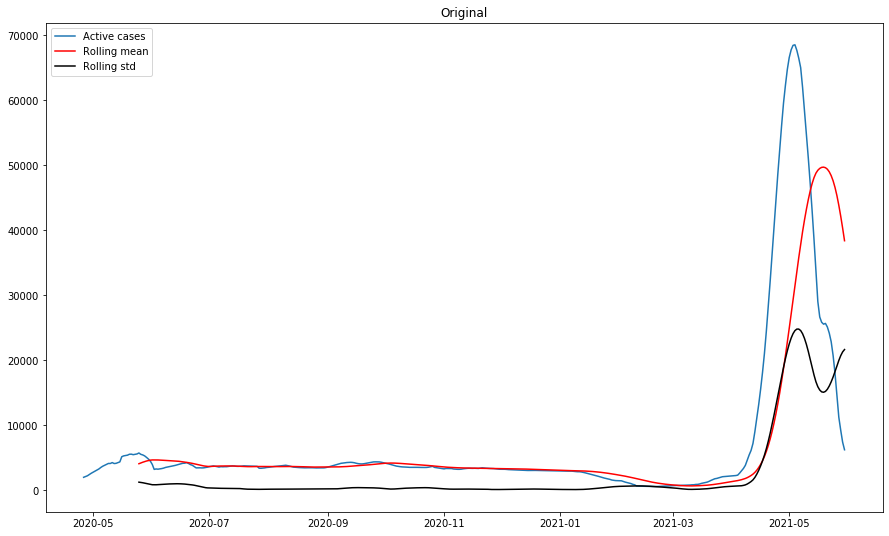

In [136]:
all_data = pd.concat([bang_data,bang_data_21])
rolmean = all_data.rolling(window=30).mean()
rolstd = all_data.rolling(window=30).std()
org = plt.plot(all_data, label = 'Active cases')
mean = plt.plot(rolmean.dropna(), color = 'Red', label = 'Rolling mean')
std = plt.plot(rolstd.dropna(), color = 'Black', label = 'Rolling std')
plt.legend()
plt.title('Original')

adftst = adfuller(all_data['Active'], autolag = 'AIC')
print(adftst)

if(adftst[1] < 0.05):
    print('Stationary')
else:
    print('Non stationary')

(-3.5130636430662565, 0.0076578624441449, 12, 386, {'1%': -3.447405233596701, '5%': -2.8690569369014605, '10%': -2.5707743450830893}, 1054.8507443095941)
Stationary


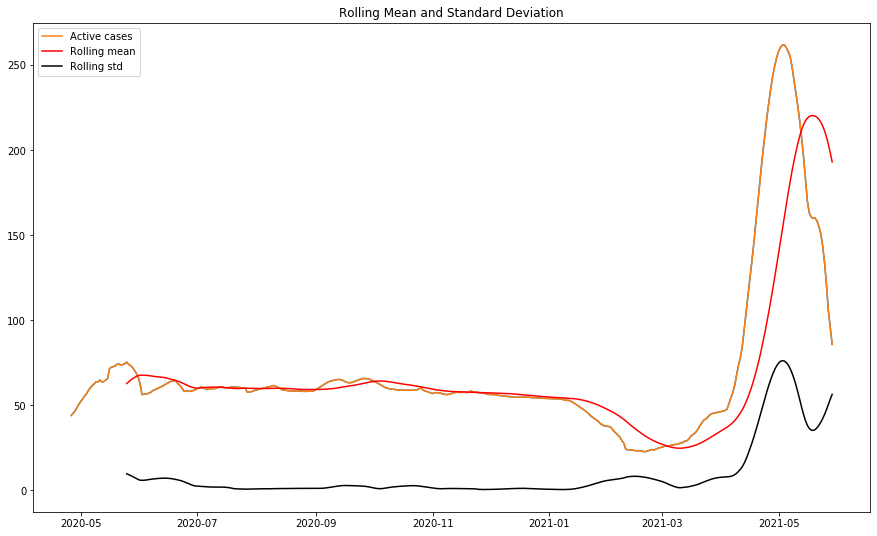

In [137]:
# Sqrt to fix non-stationarity
bang_data_sqrt = np.sqrt(all_data[:-1])
plt.plot(bang_data_sqrt)

rolmean = bang_data_sqrt.rolling(window=30).mean()
rolstd = bang_data_sqrt.rolling(window=30).std()
org = plt.plot(bang_data_sqrt, label = 'Active cases')
mean = plt.plot(rolmean.dropna(), color = 'Red', label = 'Rolling mean')
std = plt.plot(rolstd.dropna(), color = 'Black', label = 'Rolling std')
plt.legend()
plt.title('Rolling Mean and Standard Deviation')


adftst = adfuller(bang_data_sqrt['Active'], autolag = 'AIC')
print(adftst)

if(adftst[1] < 0.05):
    print('Stationary')
else:
    print('Non stationary')

(-3.2536743375523263, 0.017080563339391626, 11, 386, {'1%': -3.447405233596701, '5%': -2.8690569369014605, '10%': -2.5707743450830893}, 1063.2186912837255)
Stationary


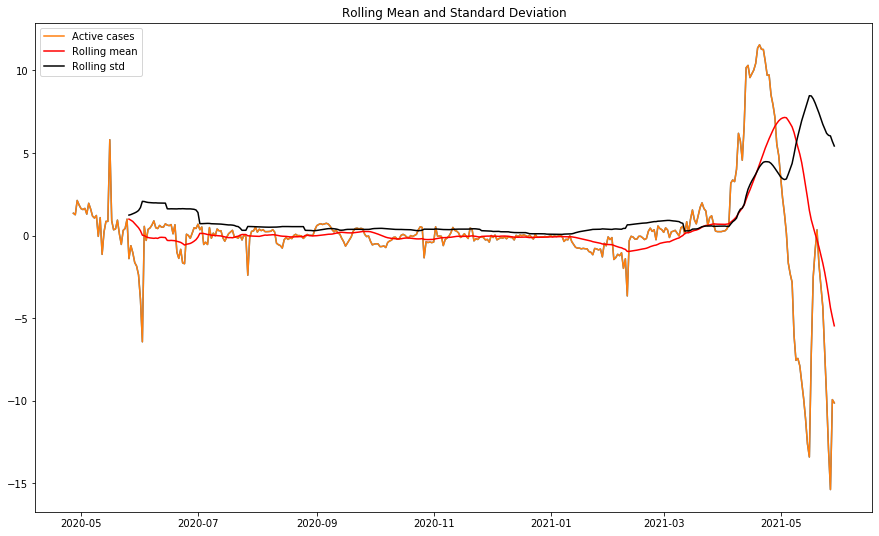

In [138]:
# Differencing method
bang_data_second = bang_data_sqrt.diff(1)
bang_data_second = bang_data_second.dropna()
plt.plot(bang_data_second)

rolmean = bang_data_second.rolling(window=30).mean()
rolstd = bang_data_second.rolling(window=30).std()
org = plt.plot(bang_data_second, label = 'Active cases')
mean = plt.plot(rolmean.dropna(), color = 'Red', label = 'Rolling mean')
std = plt.plot(rolstd.dropna(), color = 'Black', label = 'Rolling std')
plt.legend()
plt.title('Rolling Mean and Standard Deviation')


adftst = adfuller(bang_data_second['Active'].dropna(), autolag = 'AIC')
print(adftst)

if(adftst[1] < 0.05):
    print('Stationary')
else:
    print('Non stationary')

In [139]:
step_fit = auto_arima(bang_data_second['Active'].dropna(), trace = True)
step_fit.summary()

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=1126.413, Time=0.20 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=2033.554, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=1125.181, Time=0.18 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=1640.594, Time=0.07 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=2032.010, Time=0.01 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=1126.354, Time=0.09 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=1126.471, Time=0.09 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=1126.664, Time=0.25 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=1123.285, Time=0.03 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=1124.443, Time=0.04 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=1124.563, Time=0.04 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=1638.864, Time=0.04 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=1124.764, Time=0.12 sec

Best model:  ARIMA(1,0,0)(0,0,0)[0]          
Total fit time: 1.182 seconds


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  398
Model:               SARIMAX(1, 0, 0)   Log Likelihood                -559.643
Date:                Fri, 04 Jun 2021   AIC                           1123.285
Time:                        10:12:21   BIC                           1131.258
Sample:                             0   HQIC                          1126.443
                                - 398                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9584      0.007    128.909      0.000       0.944       0.973
sigma2         0.9686      0.028     35.176      0.000       0.915       1.023
===================================================================================
Ljung-Box (L1) (Q):                   0.82   Jarque-Bera (JB):              3493.26
Prob(Q):                              0.37   Prob(JB):                         0.00
Heteroskedasticity (H):               1.55   Skew:                             1.55
Prob(H) (two-sided):                  0.01   Kurtosis:                        17.18
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

0.9703542588217294


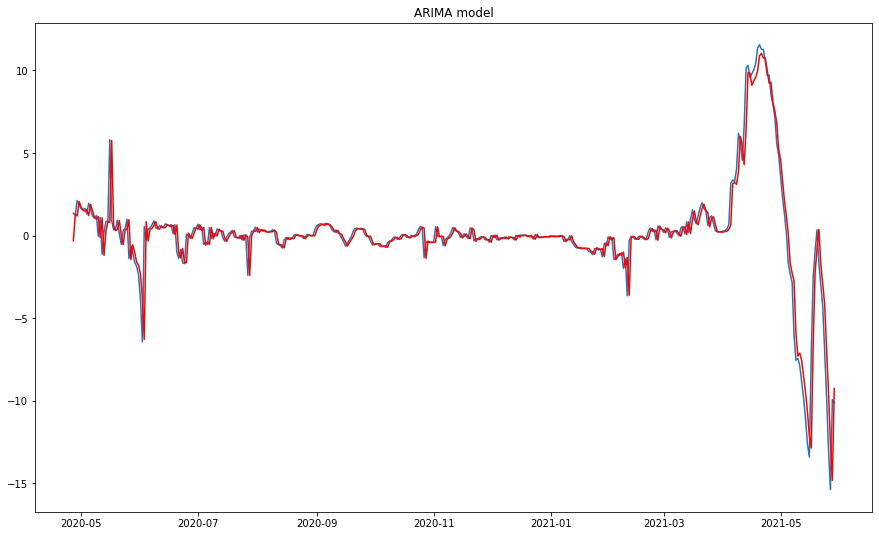

In [142]:
model = ARIMA(bang_data_sqrt,order = (2,1,0))
res_ARIMA = model.fit(disp=-1)
plt.plot(bang_data_second)
plt.plot(res_ARIMA.fittedvalues, color = 'red')
plt.title('ARIMA model')
mse = 1/len(bang_data_sqrt)*sum((res_ARIMA.fittedvalues-bang_data_second['Active'].dropna())**2)
print(mse)

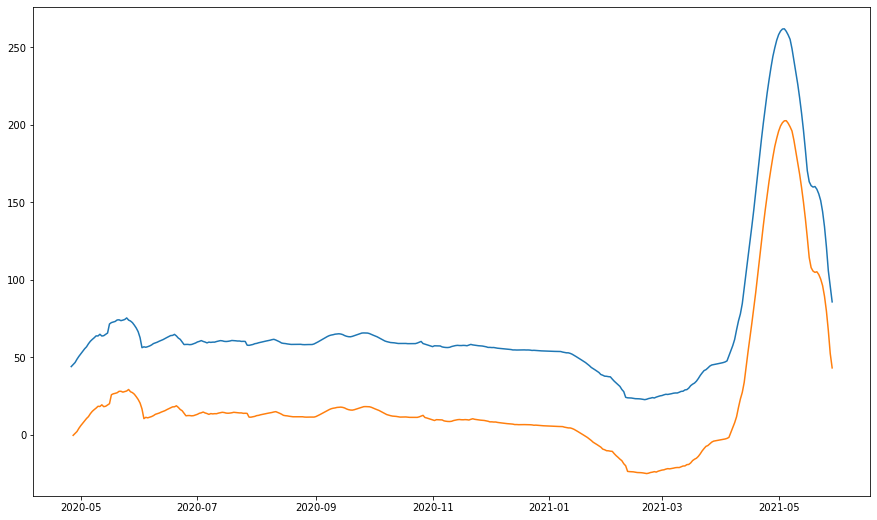

In [143]:
pred_arima = pd.Series(res_ARIMA.fittedvalues, copy=True)
pred_arima = pred_arima.cumsum()
plt.plot(bang_data_sqrt)
plt.plot(pred_arima)

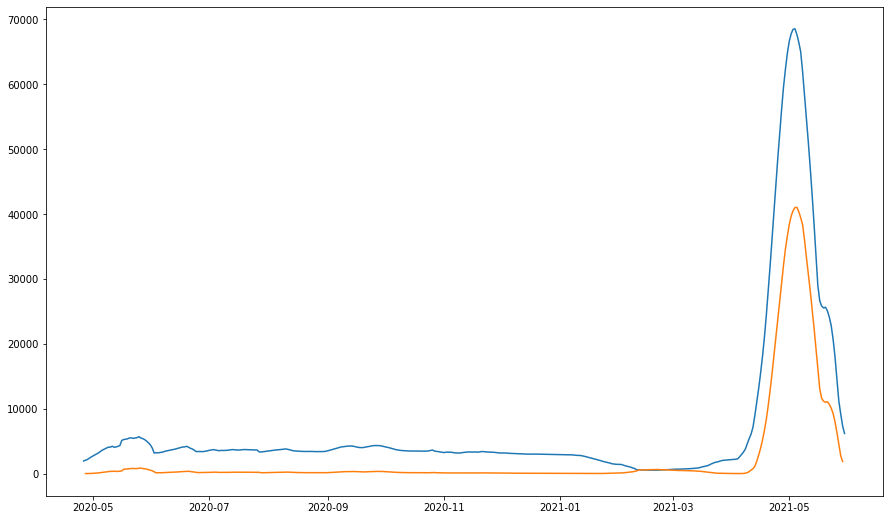

In [144]:
pred_fin = (pred_arima**2)
plt.plot(all_data)
plt.plot(pred_fin)

In [145]:
r = res_ARIMA.forecast(steps=14)
ress = r[0]**2
print(ress)

[5.77961271e+03 4.45641182e+03 3.35302324e+03 2.44542790e+03
 1.71195790e+03 1.13308448e+03 6.91216601e+02 3.70517750e+02
 1.56739690e+02 3.70716236e+01 3.34269405e-03 3.52010796e+01
 1.33394903e+02 2.86276596e+02]


            Daily       Active  Confidence Interval
Date                                               
2021-05-30   -396  5779.612713            99.779480
2021-05-31  -1323  4456.411817            99.479595
2021-06-01  -1103  3353.023243            98.922304
2021-06-02   -908  2445.427900            98.536159
2021-06-03   -734  1711.957896            98.056166
2021-06-04   -578  1133.084477            97.586447
2021-06-05   -442   691.216601            97.053625
2021-06-06   -321   370.517750            96.202238


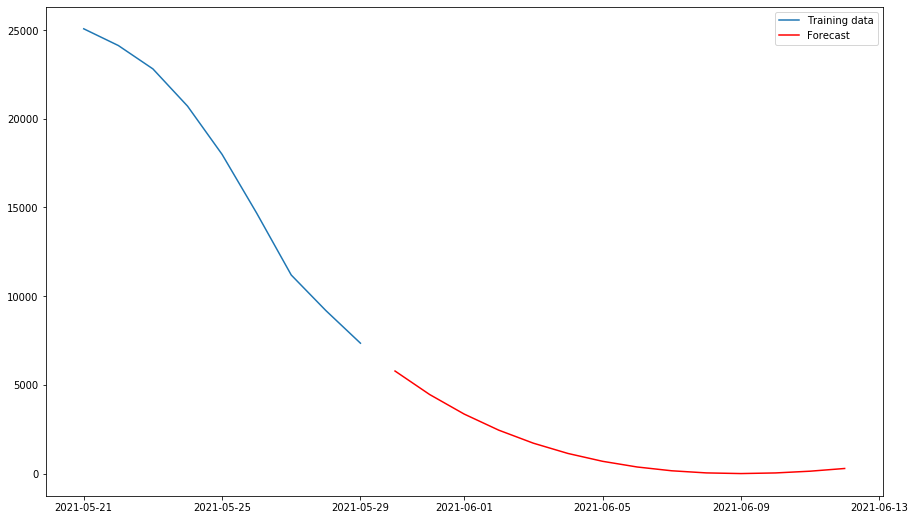

In [146]:
dt = all_data.index[-1]
end = dt + datetime.timedelta(days=len(ress))
step = datetime.timedelta(days=1)
dtframe = []
while dt < end:
    dte = (dt.strftime('%Y-%m-%d'))
    dtframe.append((datetime.datetime.strptime(dte, '%Y-%m-%d')).date())
    dt += step
    
tst = pd.DataFrame()
tst['Date'] = dtframe
daily = []
daily.append(int(ress[0])-int(all_data[-1:].values))
for i in range(1,len(ress)):
    daily.append(int(ress[i])-int(ress[i-1]))
tst['Daily'] = daily
tst['Active'] = ress
tst['Confidence Interval'] = rmse_for_tab[:len(ress)]
tst.set_index('Date',inplace=True)
print(tst[:8])
plt.plot(all_data[-10:-1])
plt.plot(tst['Active'],color='red')
plt.legend(['Training data','Forecast'])